
Launch Angle Optimisation
-------------------------
Optimal angle: 32.49 degrees
Maximum range: 3.391 m


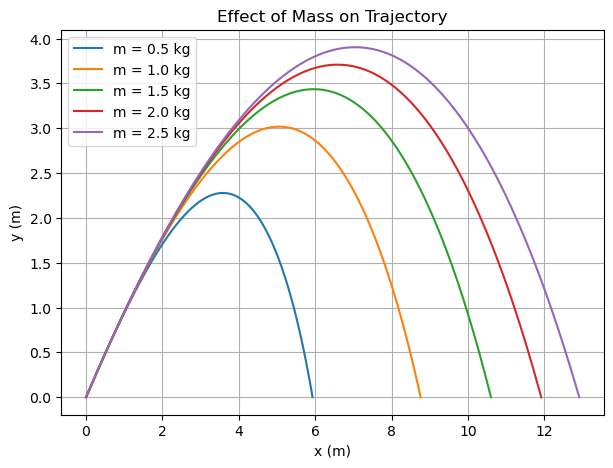

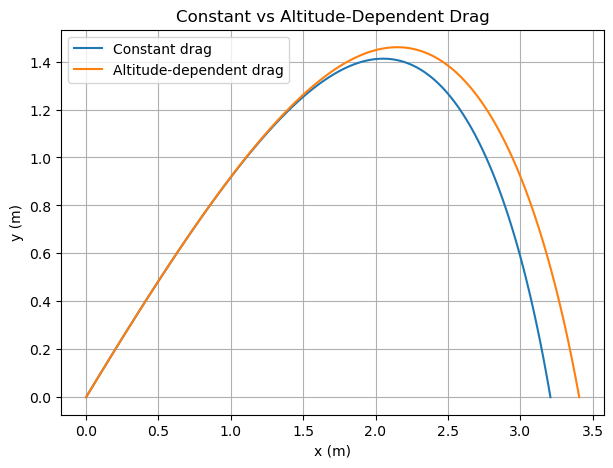

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.integrate import solve_ivp
# ============================================================
# 1. PHYSICS MODELS
# ============================================================
def projectile_ode(t, y, k, m, g):
    """
    Projectile motion with quadratic air resistance.

    State vector:
        y = [x, y, vx, vy]

    Parameters:
        k = drag coefficient
        m = mass
        g = gravitational acceleration
    """

    x, y_pos, vx, vy = y

    # Magnitude of velocity
    speed = np.sqrt(vx**2 + vy**2)

    # Position derivatives
    dxdt = vx
    dydt = vy

    # Acceleration due to quadratic drag
    dvxdt = -(k / m) * speed * vx
    dvydt = -g - (k / m) * speed * vy

    return np.array([dxdt, dydt, dvxdt, dvydt])
def projectile_ode_altitude(t, y, k0, H, m, g):
    """
    Projectile motion with quadratic drag that decreases
    exponentially with altitude.

    k(y) = k0 * exp(-y/H)

    Parameters:
        k0 = drag coefficient at ground level
        H  = characteristic height
        m  = mass
        g  = gravitational acceleration
    """

    x, y_pos, vx, vy = y

    # Drag coefficient decreases with altitude
    k = k0 * np.exp(-y_pos / H)

    # Magnitude of velocity
    speed = np.sqrt(vx**2 + vy**2)

    # Position derivatives
    dxdt = vx
    dydt = vy

    # Acceleration
    dvxdt = -(k / m) * speed * vx
    dvydt = -g - (k / m) * speed * vy

    return np.array([dxdt, dydt, dvxdt, dvydt])
# ============================================================
# 2. RK4 NUMERICAL SOLVER
# ============================================================

def rk4_step(f, t, y, dt, *args):
    """
    Perform one fourth-order Runge-Kutta (RK4) timestep.
    """

    k1 = f(t, y, *args)

    k2 = f(
        t + dt / 2,
        y + (dt / 2) * k1,
        *args
    )

    k3 = f(
        t + dt / 2,
        y + (dt / 2) * k2,
        *args
    )

    k4 = f(
        t + dt,
        y + dt * k3,
        *args
    )

    return y + (dt / 6) * (
        k1 + 2*k2 + 2*k3 + k4
    )
# ============================================================
# 3. EULER NUMERICAL SOLVER
# ============================================================

def euler_step(f, t, y, dt, *args):
    """
    Perform one Euler timestep.
    """

    return y + dt * f(t, y, *args)


# ============================================================
# 4. TRAJECTORY SIMULATOR
# ============================================================
def simulate_trajectory(
    f,
    y0,
    dt,
    t_max,
    *args,
    method='RK4'
):
    """
    Simulate projectile trajectory using either RK4 or Euler.

    The simulation stops when the projectile reaches the ground.

    Ground impact is estimated using linear interpolation between
    the last point above the ground and the first point below it.

    Returns:
        Array containing [x, y, vx, vy] at each timestep.
    """

    # Number of numerical steps
    num_steps = int(t_max / dt)

    # Storage for trajectory
    traj = np.zeros((num_steps + 1, 4))

    # Store initial condition
    traj[0] = y0.copy()

    # Current state
    y = y0.copy()

    # Current time
    t = 0.0

    # Perform simulation
    for i in range(num_steps):

        # Store previous state before taking the step
        y_previous = y.copy()

        # ----------------------------------------------------
        # Take one numerical step
        # ----------------------------------------------------

        if method.upper() == 'RK4':

            y = rk4_step(
                f,
                t,
                y,
                dt,
                *args
            )

        elif method.upper() == 'EULER':

            y = euler_step(
                f,
                t,
                y,
                dt,
                *args
            )

        else:

            raise ValueError(
                "Method must be 'RK4' or 'Euler'"
            )

        # Advance time
        t += dt

        # ----------------------------------------------------
        # Check for ground impact
        # ----------------------------------------------------

        if y[1] < 0:

            # Fraction of the timestep at which y = 0
            fraction = (
                y_previous[1]
                / (y_previous[1] - y[1])
            )

            # Interpolate the complete state
            y_impact = (
                y_previous
                + fraction * (y - y_previous)
            )

            # Force vertical position to exactly zero
            y_impact[1] = 0.0

            # Store impact state
            traj[i + 1] = y_impact

            # Return only the trajectory up to impact
            return traj[:i + 2]

        # Store normal timestep
        traj[i + 1] = y

    return traj


# ============================================================
# 5. GENERAL SIMULATION FUNCTION
# ============================================================

def run_simulation(
    m=0.2,
    k=0.1,
    g=9.81,
    y0=None,
    dt=0.01,
    t_max=2.0,
    method='RK4',
    altitude=False,
    H=10.0
):
    """
    General simulation function.

    Allows the user to switch between:
        - RK4 / Euler
        - constant drag / altitude-dependent drag
    """

    # Default initial conditions
    if y0 is None:
        y0 = np.array([
            0.0,   # x position
            0.0,   # y position
            10.0,  # horizontal velocity
            10.0   # vertical velocity
        ])

    # Select physical model
    if altitude:

        traj = simulate_trajectory(
            projectile_ode_altitude,
            y0,
            dt,
            t_max,
            k,
            H,
            m,
            g,
            method=method
        )

    else:

        traj = simulate_trajectory(
            projectile_ode,
            y0,
            dt,
            t_max,
            k,
            m,
            g,
            method=method
        )

    return traj
# ============================================================
# 6. RANGE FOR A GIVEN LAUNCH ANGLE
# ============================================================

def simulate_range(
    angle_deg,
    speed,
    m,
    k,
    g,
    dt=0.01,
    method='RK4'
):
    """
    Simulate a projectile launched at a given angle
    and return its horizontal range.
    """

    # Convert degrees to radians
    angle = np.radians(angle_deg)

    # Convert speed + angle into velocity components
    vx = speed * np.cos(angle)
    vy = speed * np.sin(angle)

    # Initial state
    y0 = np.array([
        0.0,
        0.0,
        vx,
        vy
    ])

    # Run simulation
    traj = run_simulation(
        m=m,
        k=k,
        g=g,
        y0=y0,
        dt=dt,
        t_max=10.0,
        method=method
    )

    # Return horizontal position at impact
    return traj[-1, 0]


# ============================================================
# 7. OPTIMAL LAUNCH ANGLE
# ============================================================

def find_optimal_angle(
    speed,
    m,
    k,
    g,
    dt=0.01,
    method='RK4'
):
    """
    Find the launch angle that maximises horizontal range.
    """

    result = minimize_scalar(
        lambda angle: -simulate_range(
            angle,
            speed,
            m,
            k,
            g,
            dt=dt,
            method=method
        ),
        bounds=(0, 90),
        method='bounded'
    )

    return result.x
# ============================================================
# 8. MAIN PROGRAM
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Default parameters (0,0,10,10)
    # --------------------------------------------------------

    y0 = np.array([
        0.0,
        0.0,
        10.0,
        10.0
    ])
    speed = np.sqrt(y0[2]**2 + y0[3]**2)

    dt = 0.01
    t_max = 2.0

    m = 0.2
    k = 0.1
    g = 9.81

    # ========================================================
    # A. RK4 VS EULER
    # ========================================================

    traj_rk4 = run_simulation(
        m=m,
        k=k,
        g=g,
        y0=y0,
        dt=dt,
        t_max=t_max,
        method='RK4'
    )

    traj_euler = run_simulation(
        m=m,
        k=k,
        g=g,
        y0=y0,
        dt=dt,
        t_max=t_max,
        method='Euler'
    )

    
    # ========================================================
    # B. EFFECT OF MASS
    # ========================================================

    m_values = np.arange(0.5, 3, 0.5)

    plt.figure(figsize=(7, 5))

    for m_val in m_values:

        traj = run_simulation(
            m=m_val,
            k=k,
            g=g,
            y0=y0,
            dt=dt,
            t_max=t_max,
            method='RK4'
        )

        plt.plot(
            traj[:, 0],
            traj[:, 1],
            label=f'm = {m_val} kg'
        )

    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Effect of Mass on Trajectory')

    plt.legend()
    plt.grid()


    # ========================================================
    # C. ALTITUDE-DEPENDENT DRAG
    # ========================================================

    traj_alt = run_simulation(
        m=m,
        k=k,
        g=g,
        y0=y0,
        dt=dt,
        t_max=t_max,
        method='RK4',
        altitude=True,
        H=10.0
    )

    plt.figure(figsize=(7, 5))

    plt.plot(
        traj_rk4[:, 0],
        traj_rk4[:, 1],
        label='Constant drag'
    )

    plt.plot(
        traj_alt[:, 0],
        traj_alt[:, 1],
        label='Altitude-dependent drag'
    )

    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title(
        'Constant vs Altitude-Dependent Drag'
    )

    plt.legend()
    plt.grid()

    # ========================================================
    # D. OPTIMAL LAUNCH ANGLE
    # ========================================================

    optimal_angle = find_optimal_angle(
        speed=speed,
        m=m,
        k=k,
        g=g,
        dt=dt,
        method='RK4'
    )

    optimal_range = simulate_range(
        optimal_angle,
        speed=speed,
        m=m,
        k=k,
        g=g,
        dt=dt,
        method='RK4'
    )

    print("\nLaunch Angle Optimisation")
    print("-------------------------")

    print(
        f"Optimal angle: "
        f"{optimal_angle:.2f} degrees"
    )

    print(
        f"Maximum range: "
        f"{optimal_range:.3f} m"
    )

plt.show()